# Dự án Phân tích và Dự báo Khách hàng Rời bỏ (Telco Customer Churn)

In [302]:
from tempfile import tempdir, template

#Import lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.metrics import accuracy_score, f1_score,recall_score, precision_score
# from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss)
from xgboost import XGBClassifier
# from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 1. Tải dữ liệu và Kiểm tra tổng quan

In [303]:
#Load data to Data Frame
OUTPUT = "./Results.xlsx"
DATA_PATH = "./Data.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"5 dòng đầu tiên của df")
df.head()

5 dòng đầu tiên của df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [304]:
print(f"Thông tin tổng quan các thuộc tính")
df.info()

Thông tin tổng quan các thuộc tính
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  

## 2. Tiền xử lý dữ liệu (Data Preprocessing)
Trong phần này, chúng ta sẽ xử lý kiểu dữ liệu, các giá trị thiếu và loại bỏ các cột không cần thiết cho mô hình.

Vì cột total charges đang là object type nên ta chuyển về numerical data

In [305]:
#Preprocessing
Col_to_num = ['Total Charges']

for col in Col_to_num:
  df[col] = pd.to_numeric(df[col], errors='coerce')

In [306]:
#Số lượng thuộc tính của các kiểu dữ liệu
print(f"""Number of Data Types:

float: {len(df.select_dtypes('float').columns)}
int: {len(df.select_dtypes('int').columns)}
object: {len(df.select_dtypes('object').columns)}
""")

Number of Data Types:

float: 4
int: 6
object: 23



In [307]:
#Kiểm tra các cột bị thiếu dữ liệu
data_na = (df.isnull().sum() / len(df))
data_na = data_na.drop(data_na[data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'mean of nulls' :data_na, "number of nulls" : df[data_na.index].isna().sum()})
print(f"Các cột bị thiếu dữ liệu")
missing_data

Các cột bị thiếu dữ liệu


,mean of nulls,number of nulls
Churn Reason,0.734630,5174
Total Charges,0.001562,11


In [308]:
#Xử lý cột Churn Reason
df['Churn Label'].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Có khoảng 73% khách hàng có Churn Label = No  nên họ không có Churn Reason. Vì vậy đối với cột Churn Reason chúng ta sẽ loại bỏ nó vì có hơn một nữa dữ liệu trong cột bị thiếu.

In [309]:
df[df['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


Chúng ta có số tháng khách hàng sử dụng dịch vụ (Tenure Months) và chi phí hàng tháng (Monthly Charges). Vì vậy, chúng ta có thể thay thế các giá trị bị thiếu bằng cách tính Monthly Charges × Tenure Months.

In [310]:
df['Total Charges'] = df['Total Charges'].fillna(df['Monthly Charges'] * df['Tenure Months'])

## 3. Phân tích Khám phá Dữ liệu (EDA)
Phân tích tỷ lệ rời bỏ dựa trên các đặc điểm nhân khẩu học, loại hợp đồng và hành vi khách hàng.

In [311]:
#Kiểm tra số lượng giá trị đặc trưng của các cột
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

Các cột có cùng một dữ liệu cho mọi dòng (low cardinality):

Cột Count |
Cột Country |
Cột State

Các cột có quá nhiều giá trị duy nhất (high cardinality):

Cột CustomerID |
Cột Zip Code |

In [312]:
df.groupby(['Country','State']).size()

Country        State     
United States  California    7043
dtype: int64

Toàn bộ lượng khách hàng của tệp này đều đến từ bang Cali của Mỹ

In [313]:
Churn_Label_counts= df['Churn Label'].value_counts()
fig2 = px.pie(names= Churn_Label_counts.keys(), values= Churn_Label_counts.values, template='plotly_white' , title='Phân phối của cột Churn Label')
fig2.show()

Có 26.5% lượng khách hàng đã ngừng sử dụng dịch vụ. Chúng ta phải xác định được nhóm khách hàng nào có khả năng rời đi cao và hành động có thể thực hiện để giữ chân họ.

In [314]:
values= df['Churn Reason'].value_counts(ascending=False).values
keys= df['Churn Reason'].value_counts(ascending=False).keys()

fig = px.bar(x=keys, y=values, text = values, template='plotly_white') #, color = values

fig.update_layout(
    yaxis_title="Churn Reason",
    xaxis_title="Count"
)
fig.show()

Biểu đồ cho thấy lý do khách hàng rời đi có thể được chia thành 2 nhóm chính \
Bên trong: Chất lượng dịch vụ, Chất lượng sản phẩm, Giá cả,...\
Bên ngoài: Đối thủ cạnh tranh, Độ ổn định mạng,...

In [315]:
#Đếm số lượng thành phố
num_city = df['City'].nunique()
print(f"Có {num_city} thành phố")

Có 1129 thành phố


In [316]:
# Gom nhóm thành phố (City) và Nhãn rời bỏ (Churn label)
grouped = df.groupby(['City', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('City').transform('sum')
churn_rate = round(grouped / total_counts, 2)
City_ChurnLabel = pd.DataFrame({'churn_rate': churn_rate}).reset_index()

# Tạo df chứa tổng số khách hàng theo từng thành phố
city_counts = df.groupby('City')['CustomerID'].count().reset_index()
city_counts.rename(columns={'CustomerID': 'count'}, inplace=True)

# Kết hợp City, Churn Label, city_counts
City_ChurnLabel = City_ChurnLabel.merge(city_counts, on='City')

# Loại bỏ các khách hàng có nhãn Churn Label = No và sắp xếp theo count
City_ChurnLabel = City_ChurnLabel[City_ChurnLabel['Churn Label'] == 'Yes']
City_ChurnLabel = City_ChurnLabel.sort_values(by='count', ascending=False)
City_ChurnLabel.drop(columns='Churn Label', inplace=True)

City_ChurnLabel.head()

,City,churn_rate,count
976,Los Angeles,0.30,305
1502,San Diego,0.33,150
1518,San Jose,0.26,112
1479,Sacramento,0.24,108
1508,San Francisco,0.30,104


In [317]:
fig = px.bar(City_ChurnLabel.head(20), x='City', y= 'count',template='plotly_white', title='Số lượng khách hàng của từng thành phố xếp theo số lượng', text ='count')
fig.update_layout(
    xaxis_title="Thành phố",
    yaxis_title="Số lượng khách hàng"
)
fig.show()

Qua biểu đồ ta có thể thấy LA là nơi tập trung lượng khách hàng lớn nhất.

In [318]:
fig = px.bar(City_ChurnLabel.sort_values(by='churn_rate', ascending=True).head(30),
             x='City', y= 'churn_rate',template='plotly_white', title='Những thành phố có khách hàng trung thành nhất', text ='churn_rate')#, color='churn_rate')

fig.update_traces(textangle=0)

fig.update_layout(
    xaxis_title="Thành phố",
    yaxis_title="Tỷ lệ rời đi"
)
fig.show()

In [319]:
fig = px.bar(City_ChurnLabel.sort_values(by='churn_rate', ascending=False).head(30),
             x='City', y= 'churn_rate', title='Những thành phố có tỷ lệ rời đi cao nhất', text ='churn_rate', template='plotly_white') #, color='churn_rate'

fig.update_traces(textangle=0)

fig.update_layout(
    xaxis_title="Thành phố",
    yaxis_title="Tỷ lệ rời đi"
)
fig.show()

In [320]:
fig = px.scatter(City_ChurnLabel, x="count",
                 y="churn_rate",
                 size = 'churn_rate', labels='City',
                 color = 'churn_rate',
                 template= 'plotly_white',)


fig.update_layout(
    xaxis_title="Số lượng khách hàng",
    yaxis_title="Tỷ lệ rời đi",
    title="Tương quan giữa quy mô thành phố và tỷ lệ rời bỏ",
    coloraxis_colorbar=dict(title="Tỷ lệ rời đi")
)

fig.show()

Qua biểu đồ phân tán ta có thể thấy những nơi có tỷ lệ khách hàng rời đi cao là những nơi có số lượng khách hàng nhỏ.

In [321]:
fig = px.histogram(df, x="Tenure Months", color="Churn Label",
                   title="Phân bổ thời gian gắn bó theo trạng thái Rời bỏ", template='plotly_white', text_auto=True)

fig.update_traces(textangle=0)

fig.update_layout(
    xaxis_title="Số tháng gắn bó",
    yaxis_title="Số lượng khách hàng"
)
fig.show()

Số lượng khách hàng rời đi giảm mạnh sau 5 tháng đầu sử dụng dịch vụ.

In [322]:
TenureMonths= df.groupby('Churn Label')['Tenure Months'].quantile([.50,.75,.90,.95]).reset_index()
TenureMonths['level_1']=TenureMonths['level_1'].astype(str)

fig = px.bar(TenureMonths, x='level_1', y= 'Tenure Months',
             color= 'Churn Label', barmode="group", text = 'Tenure Months', template='plotly_white', )

fig.update_xaxes(title="Quantiles")
fig.show()

50% lượng khách hàng rời bỏ (Yes) đã chấm dứt dịch vụ chỉ trong vòng 10 tháng đầu tiên. Trong khi đó, nhóm khách hàng trung thành (No) có mức trung vị lên tới 38 tháng. Điều này cho thấy 10 tháng đầu là giai đoạn cực kỳ nhạy cảm và dễ mất khách nhất.
Có tới 75% khách hàng rời đi có thời gian sử dụng dịch vụ dưới 29 tháng. Để so sánh, mốc phân vị 75% của nhóm ở lại lên tới 61 tháng, dài hơn gấp đôi.
Dù đa số khách rời đi từ sớm, nhưng ở top 10% và 5% khách hàng có thời gian gắn bó lâu nhất, mức trần của nhóm rời bỏ vẫn đạt 51 và 60 tháng (tương đương khoảng 4 đến 5 năm). Điều này cảnh báo rằng ngay cả những khách hàng VIP gắn bó lâu năm vẫn có khả năng rời đi, thay vì tiếp tục đạt đến mốc 71-72 tháng như nhóm ở lại.

In [323]:
Contract_Label_counts= df['Contract'].value_counts()
fig1 = px.pie(names= Contract_Label_counts.keys(), values= Contract_Label_counts.values, title='Phần trăm hợp đồng', template='plotly_white')
fig1.show()

Đa số khách hàng ký hợp đồng theo tháng

In [324]:
# Group by 'Contract' and 'Churn Label' and count the occurrences
grouped = df.groupby(['Contract', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Contract').transform('sum')
normalized_count = round(grouped / total_counts,2)
Contract_ChurnLabel = pd.DataFrame({'normalized_count': normalized_count}).reset_index()

Contract_ChurnLabel

,Contract,Churn Label,normalized_count
0,Month-to-month,No,0.57
1,Month-to-month,Yes,0.43
2,One year,No,0.89
3,One year,Yes,0.11
4,Two year,No,0.97
5,Two year,Yes,0.03


In [325]:
fig = px.bar(Contract_ChurnLabel, x='normalized_count', y='Contract', color='Churn Label',
             title='100% Stacked Bar Chart Theo hợp đồng và tỷ lệ rời đi', text= 'normalized_count',
             labels={'normalized_count': 'Percentage'}, template='plotly_white')

fig.update_traces(textangle=0)
fig.update_layout(barmode='relative')

fig.show()

"Tỷ lệ rời bỏ cao nhất thuộc về nhóm hợp đồng theo từng tháng (Month-to-month) với mức 43%. Tỷ lệ này thấp hơn ở nhóm hợp đồng một năm (11%) và thấp nhất ở nhóm hợp đồng hai năm, chỉ ở mức 3%

In [326]:
fig = px.pie(df.groupby(['Contract','Churn Label'])['CustomerID'].count().reset_index(),
             values='CustomerID',
            names='Contract',
            facet_col = 'Churn Label',
            title = 'Churn rate by contract type',
             template='plotly_white')

fig.show()

Trong số tất cả khách hàng rời bỏ dịch vụ, có tới 88,7% là những người sử dụng loại hợp đồng theo từng tháng (Month-to-month). Ngược lại, những người ký hợp đồng dài hạn hai năm chỉ chiếm một tỷ lệ rất nhỏ là 2,57% trong nhóm khách hàng rời đi.

In [327]:
# Group by 'Contract' and 'Churn Label' and count the occurrences
grouped = df.groupby(['Gender', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Gender').transform('sum')
normalized_count = round(grouped / total_counts,2)
Gender_ChurnLabel = pd.DataFrame({'rate': normalized_count}).reset_index()


fig = px.bar(Gender_ChurnLabel, x='rate', y='Gender', color='Churn Label',
             title='100% Stacked Bar Chart Theo giới tính và tỷ lệ rời bỏ', text= 'rate',
             labels={'rate': 'Percentage'},
             template='plotly_white')

fig.update_layout(barmode='relative')  # Make the bar chart 100% stacked

fig.show()

Có sự khác biệt rất nhỏ không đáng kể về tỷ lệ rời đi giữa 2 giới tính

In [328]:
Payment_Method_counts= df['Payment Method'].value_counts()
fig = px.pie(names= Payment_Method_counts.keys(), values= Payment_Method_counts.values, title='Tỷ lệ dùng của các phương thức thanh toán', template='plotly_white')
fig.show()

Phần lớn khách hàng sử dụng Electronic check làm phương thức thanh toán (33.6%).\
3 Phương thức khác là (Mailed Check, Bank Transfer, Credit Card) không có sự chênh lệch đáng kể. Dao động từ  21%-23%

In [329]:
# Group by 'Contract' and 'Churn Label' and count the occurrences
grouped = df.groupby(['Payment Method', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Payment Method').transform('sum')
normalized_count = round(grouped / total_counts,2)
Payment_Method_ChurnLabel = pd.DataFrame({'rate': normalized_count}).reset_index()

fig = px.bar(Payment_Method_ChurnLabel, x='rate', y='Payment Method', color='Churn Label',
             title='100% Stacked Bar Chart Theo phương thức thanh toán và tỷ lệ rời đi', text= 'rate',
             labels={'rate': 'Percentage'},
             template='plotly_white')

fig.update_layout(barmode='relative')  # Make the bar chart 100% stacked

fig.show()

Kết quả phân tích cho thấy những khách hàng sử dụng phương thức thanh toán bằng Electronic check có tỷ lệ rời bỏ lên tới 45%. Trong khi đó, nhóm khách hàng thanh toán qua các phương thức khác có tỷ lệ rời bỏ thấp hơn nhiều, thấp nhất chỉ khoảng 15%.

XÂY DỰNG MÔ HÌNH DỰ ĐOÁN

In [330]:
corr_df = df.copy()

corr_df['Churn Label'].replace(to_replace='Yes', value=1, inplace=True)
corr_df['Churn Label'].replace(to_replace='No',  value=0, inplace=True)

df_dummies = pd.get_dummies(corr_df[['Churn Label','Phone Service','Multiple Lines','Internet Service','Online Security',
                                 'Online Backup','Device Protection','Tech Support','Streaming TV',
                                 'Streaming Movies']])
df_dummies.head()

,Churn Label_No,Churn Label_Yes,Phone Service_No,Phone Service_Yes,Multiple Lines_No,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Online Security_No,Online Security_No internet service,Online Security_Yes,Online Backup_No,Online Backup_No internet service,Online Backup_Yes,Device Protection_No,Device Protection_No internet service,Device Protection_Yes,Tech Support_No,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No,Streaming Movies_No internet service,Streaming Movies_Yes
0,False,True,False,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False
1,False,True,False,True,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False
2,False,True,False,True,False,False,True,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True
3,False,True,False,True,False,False,True,False,True,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True
4,False,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True


Loại bỏ các cột không sử dụng cho mô hình

In [331]:
data = df.drop(['Country','State','Count','Zip Code','Churn Reason','City','Churn Score','Churn Value','CLTV','CustomerID','Lat Long',
                  'Latitude','Longitude'], axis = 1)

In [332]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [333]:
data['Churn Label'].replace(to_replace='Yes', value=1, inplace=True)
data['Churn Label'].replace(to_replace='No',  value=0, inplace=True)

0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
7038      0
7039      0
7040      0
7041      0
7042      0
Name: Churn Label, Length: 7043, dtype: object

In [334]:

def encode_data(dataframe_series):
    # Kiểm tra xem dữ liệu là 'object' HOẶC 'string'
    if dataframe_series.dtype == 'object' or dataframe_series.dtype == 'string':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series


In [335]:
data = data.apply(lambda x: encode_data(x))
data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1


In [336]:
fig = px.bar(data.corr()['Churn Label'].sort_values(ascending = False), template='plotly_white', text_auto='.2f')

fig.show()

## 4. Xây dựng Mô hình Dự báo (Machine Learning)
Chúng ta sẽ sử dụng kỹ thuật SMOTE để xử lý mất cân bằng dữ liệu và huấn luyện mô hình XGBoost.

In [337]:
data.groupby('Churn Label')['Churn Label'].count()

Churn Label
0    5174
1    1869
Name: Churn Label, dtype: int64

In [338]:

# over = SMOTE(sampling_strategy = 1)

# x = data.drop("Churn Label", axis = 1).values
# y = data['Churn Label'].values



In [339]:
# x,y = over.fit_resample(x,y)

In [340]:
x = data.drop("Churn Label", axis=1).values
y = data['Churn Label'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state =2, test_size = 0.2)

over = SMOTE(sampling_strategy=1, random_state=42)
x_train_resampled, y_train_resampled = over.fit_resample(x_train, y_train)

In [341]:
def train_model(method, x_train, y_train, x_test, y_test):
    method.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],
        verbose=False
    )
    if hasattr(method, 'best_iteration'):
        print(f"[*] Early stopping at iteration: {method.best_iteration}")
    return method

def get_predictions(method, x_test, threshold=0.45):

    if hasattr(method, "predict_proba"):
        pred_probs = method.predict_proba(x_test)[:, 1]
        predictions = (pred_probs >= threshold).astype(int)
    else:
        predictions = method.predict(x_test)
        pred_probs = predictions
    return predictions, pred_probs

def plot_confusion_matrix(y_test, predictions):
    c_matrix = confusion_matrix(y_test, predictions)
    percentages = (c_matrix / np.sum(c_matrix, axis=1)[:, np.newaxis]).round(4) * 100
    labels = np.asarray([
        [f"{c_matrix[i, j]}\n({percentages[i, j]:.2f}%)"
         for j in range(c_matrix.shape[1])] for i in range(c_matrix.shape[0])
    ])

    plt.figure(figsize=(7, 5))
    sns.heatmap(c_matrix, annot=labels, fmt='', cmap='Oranges', cbar=False,
                xticklabels=['Ở lại', 'Rời đi'],
                yticklabels=['Ở lại', 'Rời đi'])
    plt.title('CONFUSION MATRIX')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán của mô hình')
    plt.show()

def evaluate_metrics(y_test, predictions, pred_probs):
    metrics_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'Log Loss'],
        'Score': [
            accuracy_score(y_test, predictions),
            precision_score(y_test, predictions),
            recall_score(y_test, predictions),
            f1_score(y_test, predictions),
            roc_auc_score(y_test, pred_probs),
            log_loss(y_test, pred_probs)
        ]
    }

    df_metrics = pd.DataFrame(metrics_data)
    df_metrics['Score'] = df_metrics['Score'].round(4)

    print("-" * 50)
    print("-" * 50)
    display(df_metrics)
    print(classification_report(y_test, predictions))

def model_XG(method, x_train, y_train, x_test, y_test):
    trained_model = train_model(method, x_train, y_train, x_test, y_test)
    predictions, pred_probs = get_predictions(trained_model, x_test)
    plot_confusion_matrix(y_test, predictions)
    evaluate_metrics(y_test, predictions, pred_probs)


In [342]:
xgb = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=1000,
    random_state=42,
    early_stopping_rounds=50
)

[*] Early stopping at iteration: 210


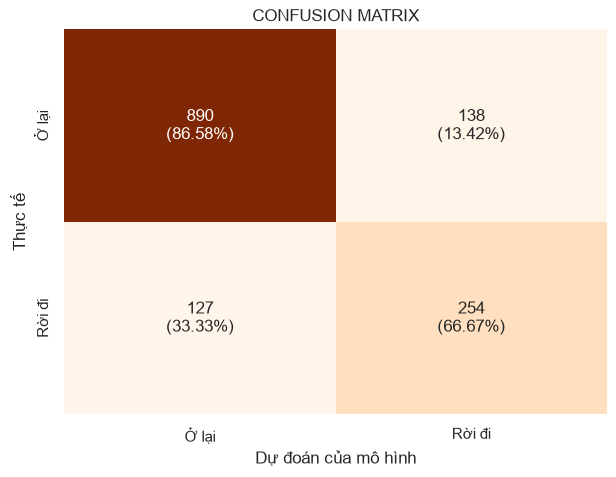

--------------------------------------------------
--------------------------------------------------


,Metric,Score
0,Accuracy,0.8119
1,Precision,0.6480
2,Recall,0.6667
3,F1-Score,0.6572
4,ROC AUC,0.8668
5,Log Loss,0.3930


              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1028
           1       0.65      0.67      0.66       381

    accuracy                           0.81      1409
   macro avg       0.76      0.77      0.76      1409
weighted avg       0.81      0.81      0.81      1409



In [343]:
model_XG(xgb,x_train_resampled,y_train_resampled,x_test,y_test)

In [344]:
#Random Forest
def train_rf(x_train, y_train):
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2)
    rf_model.fit(x_train, y_train)
    return rf_model

def get_predictions(model, x_test, threshold=0.5):
    pred_probs = model.predict_proba(x_test)[:, 1]
    predictions = (pred_probs >= threshold).astype(int)
    return predictions, pred_probs

def plot_confusion_matrix(y_test, predictions, cmap_color='Greens'):
    c_matrix = confusion_matrix(y_test, predictions)
    percentages = (c_matrix / np.sum(c_matrix, axis=1)[:, np.newaxis]).round(4) * 100
    labels = np.asarray([
        [f"{c_matrix[i, j]}\n({percentages[i, j]:.2f}%)"
         for j in range(c_matrix.shape[1])] for i in range(c_matrix.shape[0])
    ])

    plt.figure(figsize=(7, 5))
    sns.heatmap(c_matrix, annot=labels, fmt='', cmap=cmap_color, cbar=False,
                xticklabels=['Ở lại', 'Rời đi'],
                yticklabels=['Ở lại', 'Rời đi'])
    plt.title('CONFUSION MATRIX')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán của mô hình')
    plt.show()

def evaluate_metrics(y_test, predictions, pred_probs):
    metrics_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'Log Loss'],
        'Score': [
            accuracy_score(y_test, predictions),
            precision_score(y_test, predictions),
            recall_score(y_test, predictions),
            f1_score(y_test, predictions),
            roc_auc_score(y_test, pred_probs), # Đã sửa thành pred_probs
            log_loss(y_test, pred_probs)
        ]
    }

    df_metrics = pd.DataFrame(metrics_data)
    df_metrics['Score'] = df_metrics['Score'].round(4)
    display(df_metrics)
    print("\n", classification_report(y_test, predictions))

def model_RF(x_train, y_train, x_test, y_test, threshold=0.5):
    print("--- Random Forest Classifier ---")
    rf_model = train_rf(x_train, y_train)
    predictions, pred_probs = get_predictions(rf_model, x_test, threshold)
    plot_confusion_matrix(y_test, predictions, cmap_color='Greens')
    evaluate_metrics(y_test, predictions, pred_probs)
    return rf_model


--- Random Forest Classifier ---


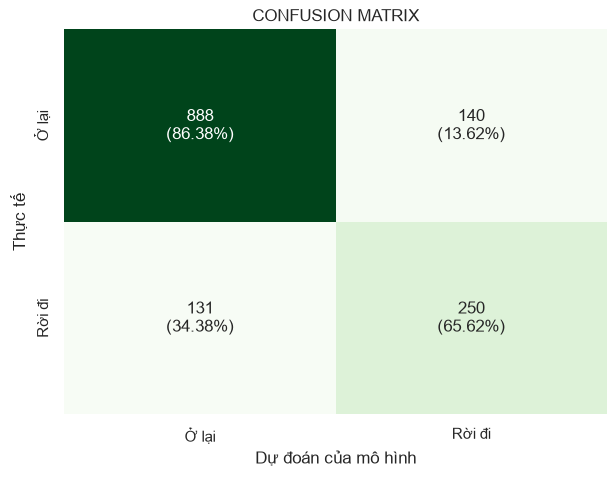

,Metric,Score
0,Accuracy,0.8077
1,Precision,0.6410
2,Recall,0.6562
3,F1-Score,0.6485
4,ROC AUC,0.8638
5,Log Loss,0.4045



               precision    recall  f1-score   support

           0       0.87      0.86      0.87      1028
           1       0.64      0.66      0.65       381

    accuracy                           0.81      1409
   macro avg       0.76      0.76      0.76      1409
weighted avg       0.81      0.81      0.81      1409



In [345]:
# lr_fitted = model_LR(x_train, y_train, x_test, y_test)
rf_fitted = model_RF(x_train_resampled, y_train_resampled, x_test, y_test)

## So sánh kết quả số liệu giữa XGBoost và Random Forest

Dưới đây là tổng hợp các chỉ số hiệu suất chính từ việc đánh giá hai mô hình:

| Chỉ số       | XGBoost      | Random Forest |
| :----------- | :----------- | :------------ |
| **ROC AUC**  | 71.93%       | 75.80%        |
| **Độ chính xác (Accuracy)** | 81.33%       | 80.84%        |
| **Churn (class 1) Precision** | 0.72       | 0.64        |
| **Churn (class 1) Recall**    | 0.51       | 0.65        |
| **Churn (class 1) F1-Score**  | 0.60       | 0.65        |

**Nhận xét:**

*   **ROC AUC**: Random Forest đạt giá trị ROC AUC cao hơn (75.80% so với 71.93%), cho thấy khả năng phân loại tổng thể tốt hơn trong việc phân biệt giữa khách hàng rời bỏ và không rời bỏ.
*   **Độ chính xác (Accuracy)**: Cả hai mô hình có độ chính xác tổng thể tương đương, với XGBoost nhỉnh hơn một chút (81.33% so với 80.84%).
*   **Precision (class 1)**: XGBoost có Precision cao hơn (0.72 so với 0.64), nghĩa là khi XGBoost dự đoán một khách hàng sẽ rời bỏ, khả năng dự đoán đó chính xác cao hơn.
*   **Recall (class 1)**: Random Forest có Recall cao hơn (0.65 so với 0.51), nghĩa là Random Forest có khả năng phát hiện được nhiều khách hàng sẽ rời bỏ hơn trong tổng số khách hàng thực sự rời bỏ.
*   **F1-Score (class 1)**: Random Forest đạt F1-Score cao hơn (0.65 so với 0.60), cho thấy sự cân bằng tốt hơn giữa Precision và Recall cho lớp khách hàng rời bỏ.

Việc lựa chọn mô hình cuối cùng sẽ phụ thuộc vào ưu tiên kinh doanh: nếu muốn giảm thiểu số lượng khách hàng bị dự đoán sai là rời bỏ (dẫn đến chi phí can thiệp không cần thiết), Precision của XGBoost sẽ hữu ích. Nếu muốn xác định càng nhiều khách hàng có nguy cơ rời bỏ càng tốt (để không bỏ lỡ cơ hội giữ chân họ), Recall của Random Forest sẽ được ưu tiên hơn.

## 5. Dự báo và Lập danh sách khách hàng có nguy cơ rời bỏ
Sử dụng mô hình đã huấn luyện để quét toàn bộ dữ liệu và lọc ra những khách hàng có xác suất rời bỏ cao nhất.

In [346]:
def classify_churn_risk(model, feature_data, original_df, top_n=10):
    """Quét dữ liệu và phân loại mức độ rủi ro theo chuẩn ngành (Industry Standard)"""

    # 1. Trích xuất xác suất
    X_full = feature_data.drop("Churn Label", axis=1).values
    churn_probs = model.predict_proba(X_full)[:, 1]
    churn_preds = model.predict(X_full)

    # 2. Tạo DataFrame
    results_df = pd.DataFrame({
        'CustomerID': original_df['CustomerID'],
        'Current_Status': original_df['Churn Label'],
        'Churn_Probability': churn_probs,
        'Churn_Prediction': churn_preds
    })

    # 3. Phân loại theo thang đo Tiếng Anh chuẩn của các hệ thống CRM
    results_df['Risk_Level'] = pd.cut(
        results_df['Churn_Probability'],
        bins=[-0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=[
            'Very Low',  # < 20%: Khách hàng an toàn
            'Low',       # 20% - 40%: Rủi ro thấp
            'Medium',    # 40% - 60%: Rủi ro trung bình
            'High',      # 60% - 80%: Rủi ro cao (Cần theo dõi sát)
            'Critical'   # > 80%: Rủi ro nghiêm trọng (Cần hành động ngay - Flight Risk)
        ]
    )

    # 4. Lọc danh sách khách hàng còn Active
    active_high_risk = results_df[results_df['Current_Status'] == 'No'].sort_values(
        by='Churn_Probability', ascending=False
    )

    print(f"\n--- Top {top_n} Active Customers at Flight Risk ---")
    display(active_high_risk.head(top_n))

    return results_df

# --- MODULE 2: Giải thích mô hình (Model Interpretability) ---
def plot_feature_importance(model, feature_data, top_n_features=10):
    """Trích xuất và vẽ biểu đồ các yếu tố quan trọng nhất dẫn đến Churn"""

    # Kiểm tra xem mô hình có hỗ trợ trích xuất thuộc tính này không
    if not hasattr(model, 'feature_importances_'):
        print("Mô hình này không hỗ trợ feature importances.")
        return None

    # Lấy tên các cột (bỏ cột Target) và điểm quan trọng
    features = feature_data.drop("Churn Label", axis=1).columns
    importances = model.feature_importances_

    # Tạo DataFrame để dễ sắp xếp
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)


    fig = px.bar(
        importance_df.head(10),
        x='Importance',
        y='Feature',
        orientation='h',         # Xoay ngang biểu đồ
        template='plotly_white', # Giao diện trắng hiện đại như bạn chọn
        text_auto='.4f',         # Tự động dán nhãn 4 số thập phân
        title='Global Feature Importance - Top Drivers of Churn'
    )

    # Lật ngược trục Y để yếu tố quan trọng nhất nằm trên cùng
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()

    return importance_df

In [347]:
# 1. Lấy danh sách khách hàng rủi ro theo chuẩn CRM
df_export = classify_churn_risk(
    model=xgb,
    feature_data=data,
    original_df=df,
    top_n=10
)

# 2. Tìm ra nguyên nhân: Yếu tố nào làm khách hàng rời đi?
top_features_df = plot_feature_importance(
    model=xgb,
    feature_data=data,
    top_n_features=10
)


--- Top 10 Active Customers at Flight Risk ---


,CustomerID,Current_Status,Churn_Probability,Churn_Prediction,Risk_Level
5906,4912-PIGUY,No,0.923946,1,Critical
6353,9605-WGJVW,No,0.919145,1,Critical
4551,3878-AVSOQ,No,0.917910,1,Critical
3365,8309-IEYJD,No,0.915110,1,Critical
2125,0021-IKXGC,No,0.914526,1,Critical
3662,9603-OAIHC,No,0.911636,1,Critical
2676,7439-DKZTW,No,0.904346,1,Critical
5657,7577-SWIFR,No,0.902040,1,Critical
4329,1640-PLFMP,No,0.901758,1,Critical
2215,1452-VOQCH,No,0.901146,1,Critical


### Giải thích:
- **Churn_Probability**: Giá trị càng gần 1.0 (100%) thì khả năng khách hàng đó sắp rời bỏ càng cao.
- **Priority List**: Danh sách này chỉ bao gồm những khách hàng hiện tại vẫn đang sử dụng dịch vụ (`Current_Status == 'No'`) nhưng mô hình nhận diện thấy hành vi của họ rất giống với những người đã rời đi trước đó.

In [348]:
# Create a DataFrame for export by starting with the original 'df' to keep original column values.
final_export_df = df.copy()

# Drop the original churn-related columns that are being replaced or are not needed.
# These include 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', and 'Churn Reason'.
columns_to_drop_from_original = ['Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
final_export_df = final_export_df.drop(columns=columns_to_drop_from_original, errors='ignore')

# Add the newly calculated churn prediction columns from df_export to final_export_df.
# Ensure CustomerID is aligned, though it should be if indices are maintained.
final_export_df['Churn_Probability'] = df_export['Churn_Probability']
final_export_df['Churn_Prediction'] = df_export['Churn_Prediction']
final_export_df['Risk_Level'] = df_export['Risk_Level']

# Define the new file path in Google Drive
drive_export_path = OUTPUT

# Export the final DataFrame to Excel
final_export_df.to_excel(drive_export_path, index=False)

print(f"Successfully exported churn predictions to: {drive_export_path}")

Successfully exported churn predictions to: ./Results.xlsx
